# Paper Figures

This notebook creates paper-facing figures from `results/summary/`.

Recommended placement:

- Main paper: shared-retrieval context and pairwise-vs-3-way conversion overview
- Appendix: subject-pair heatmaps for the pairwise conversion benchmark


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

SUMMARY_DIR = ROOT / "results" / "summary"
FIGURE_DIR = ROOT / "results" / "paper" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

retrieval_summary = pd.read_csv(SUMMARY_DIR / "retrieval_summary.csv")
conversion_summary = pd.read_csv(SUMMARY_DIR / "conversion_summary.csv")
conversion_by_pair = pd.read_csv(SUMMARY_DIR / "conversion_by_pair.csv")

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


In [3]:
POOL_LABELS = {
    "shared-eeg-meg": "EEG↔MEG",
    "shared-eeg-fmri": "EEG↔fMRI",
    "shared-fmri-meg": "MEG↔fMRI",
    "shared-eeg-fmri-meg": "EEG↔MEG↔fMRI",
}
MODALITY_ORDER = ["eeg", "meg", "fmri"]
COLOR_BY_POOL = {
    "shared-eeg-meg": "#355070",
    "shared-eeg-fmri": "#6D597A",
    "shared-fmri-meg": "#B56576",
    "shared-eeg-fmri-meg": "#E56B6F",
}

def pool_label(shared_group):
    return POOL_LABELS.get(shared_group, shared_group)

def save_figure(fig, stem):
    png_path = FIGURE_DIR / f"{stem}.png"
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved {png_path}")
    print(f"Saved {pdf_path}")

def retrieval_retention_frame():
    full_lookup = {
        row["modality"]: row["m2i_two_way_mean"]
        for _, row in retrieval_summary.query("evaluation_scope == 'full' and shared_only == False").iterrows()
    }
    shared_df = retrieval_summary.query("shared_only == True").copy()
    shared_df["retained_two_way"] = shared_df.apply(
        lambda row: row["m2i_two_way_mean"] / full_lookup[row["modality"]],
        axis=1,
    )
    return shared_df

def expanded_conversion_summary(scope):
    rows = []
    df = conversion_summary.query("evaluation_scope == @scope").copy()
    for _, row in df.iterrows():
        rows.append(
            {
                "Direction": f"{row['source_modality'].upper()}→{row['target_modality'].upper()}",
                "Shared Pool": pool_label(row["shared_group"]),
                "shared_group": row["shared_group"],
                "normalized_two_way": row["forward_normalized_two_way_mean"],
                "normalized_two_way_std": row["forward_normalized_two_way_std"],
                "two_way": row["forward_two_way_mean"],
            }
        )
        rows.append(
            {
                "Direction": f"{row['target_modality'].upper()}→{row['source_modality'].upper()}",
                "Shared Pool": pool_label(row["shared_group"]),
                "shared_group": row["shared_group"],
                "normalized_two_way": row["reverse_normalized_two_way_mean"],
                "normalized_two_way_std": row["reverse_normalized_two_way_std"],
                "two_way": row["reverse_two_way_mean"],
            }
        )
    return pd.DataFrame(rows)


Saved /Users/thomas/Documents/Projects/brainalign_ext_meg_fmri/results/paper/figures/fig1_shared_retrieval_context.png
Saved /Users/thomas/Documents/Projects/brainalign_ext_meg_fmri/results/paper/figures/fig1_shared_retrieval_context.pdf


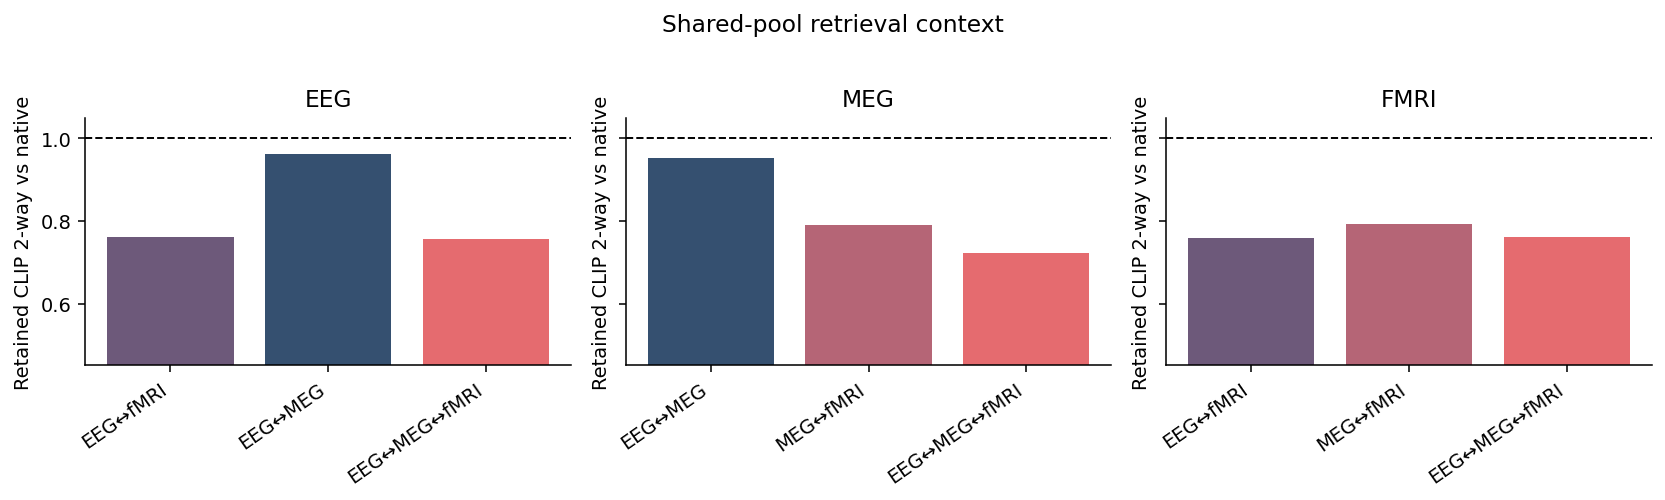

In [4]:
retention_df = retrieval_retention_frame()
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)

for ax, modality in zip(axes, MODALITY_ORDER):
    subset = retention_df[retention_df["modality"] == modality].copy()
    subset = subset.sort_values(["evaluation_scope", "shared_group"])
    x = np.arange(len(subset))
    colors = [COLOR_BY_POOL[group] for group in subset["shared_group"]]
    ax.bar(x, subset["retained_two_way"], color=colors)
    ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
    ax.set_ylim(0.45, 1.05)
    ax.set_title(modality.upper())
    ax.set_xticks(x)
    ax.set_xticklabels(
        [pool_label(group) for group in subset["shared_group"]],
        rotation=35,
        ha="right",
    )
    ax.set_ylabel("Retained CLIP 2-way vs native")

fig.suptitle("Shared-pool retrieval context")
fig.tight_layout(rect=(0, 0, 1, 0.96))
save_figure(fig, "fig1_shared_retrieval_context")
plt.show()


Saved /Users/thomas/Documents/Projects/brainalign_ext_meg_fmri/results/paper/figures/fig2_conversion_overview.png
Saved /Users/thomas/Documents/Projects/brainalign_ext_meg_fmri/results/paper/figures/fig2_conversion_overview.pdf


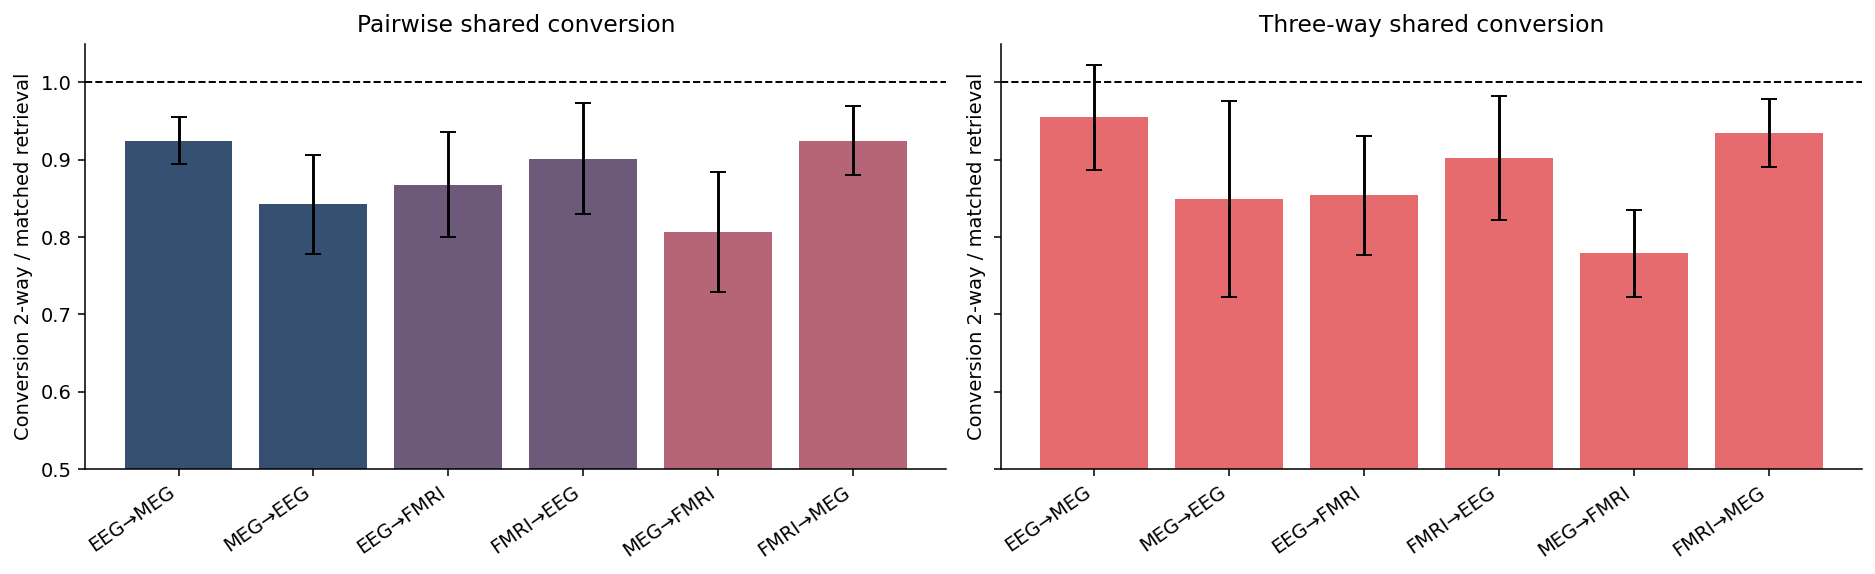

In [5]:
pair_df = expanded_conversion_summary("pair")
three_way_df = expanded_conversion_summary("three_way")
direction_order = [
    "EEG→MEG",
    "MEG→EEG",
    "EEG→FMRI",
    "FMRI→EEG",
    "MEG→FMRI",
    "FMRI→MEG",
]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), sharey=True)
for ax, data, title in [
    (axes[0], pair_df, "Pairwise shared conversion"),
    (axes[1], three_way_df, "Three-way shared conversion"),
]:
    data = data.set_index("Direction").loc[direction_order].reset_index()
    x = np.arange(len(data))
    colors = [COLOR_BY_POOL[group] for group in data["shared_group"]]
    ax.bar(
        x,
        data["normalized_two_way"],
        yerr=data["normalized_two_way_std"],
        capsize=4,
        color=colors,
    )
    ax.axhline(1.0, color="black", linewidth=1, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(data["Direction"], rotation=35, ha="right")
    ax.set_ylim(0.5, 1.05)
    ax.set_title(title)
    ax.set_ylabel("Conversion 2-way / matched retrieval")

fig.tight_layout()
save_figure(fig, "fig2_conversion_overview")
plt.show()


Saved /Users/thomas/Documents/Projects/brainalign_ext_meg_fmri/results/paper/figures/figA1_pairwise_conversion_heatmaps.png
Saved /Users/thomas/Documents/Projects/brainalign_ext_meg_fmri/results/paper/figures/figA1_pairwise_conversion_heatmaps.pdf


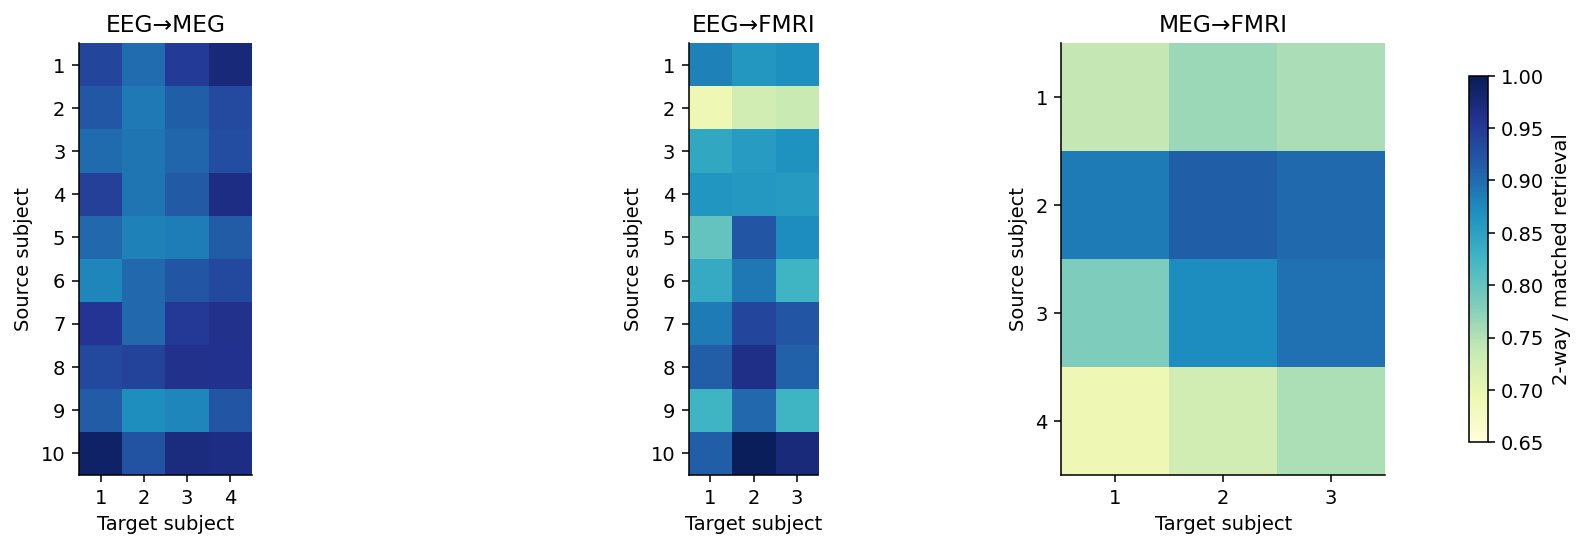

In [6]:
pair_heatmap_specs = [
    ("shared-eeg-meg", "eeg", "meg"),
    ("shared-eeg-fmri", "eeg", "fmri"),
    ("shared-fmri-meg", "meg", "fmri"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
for ax, (group, source_modality, target_modality) in zip(axes, pair_heatmap_specs):
    subset = conversion_by_pair[
        (conversion_by_pair["evaluation_scope"] == "pair")
        & (conversion_by_pair["shared_group"] == group)
        & (conversion_by_pair["source_modality"] == source_modality)
        & (conversion_by_pair["target_modality"] == target_modality)
    ]
    heatmap = subset.pivot(
        index="source_subject",
        columns="target_subject",
        values="forward_normalized_two_way",
    )
    image = ax.imshow(heatmap.values, vmin=0.65, vmax=1.0, cmap="YlGnBu")
    ax.set_title(f"{source_modality.upper()}→{target_modality.upper()}")
    ax.set_xlabel("Target subject")
    ax.set_ylabel("Source subject")
    ax.set_xticks(range(len(heatmap.columns)))
    ax.set_xticklabels(heatmap.columns)
    ax.set_yticks(range(len(heatmap.index)))
    ax.set_yticklabels(heatmap.index)

fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.85, label="2-way / matched retrieval")
save_figure(fig, "figA1_pairwise_conversion_heatmaps")
plt.show()


Saved /Users/thomas/Documents/Projects/brainalign_ext_meg_fmri/results/paper/figures/figA2_modality_level_normalized_two_way_pair.png
Saved /Users/thomas/Documents/Projects/brainalign_ext_meg_fmri/results/paper/figures/figA2_modality_level_normalized_two_way_pair.pdf


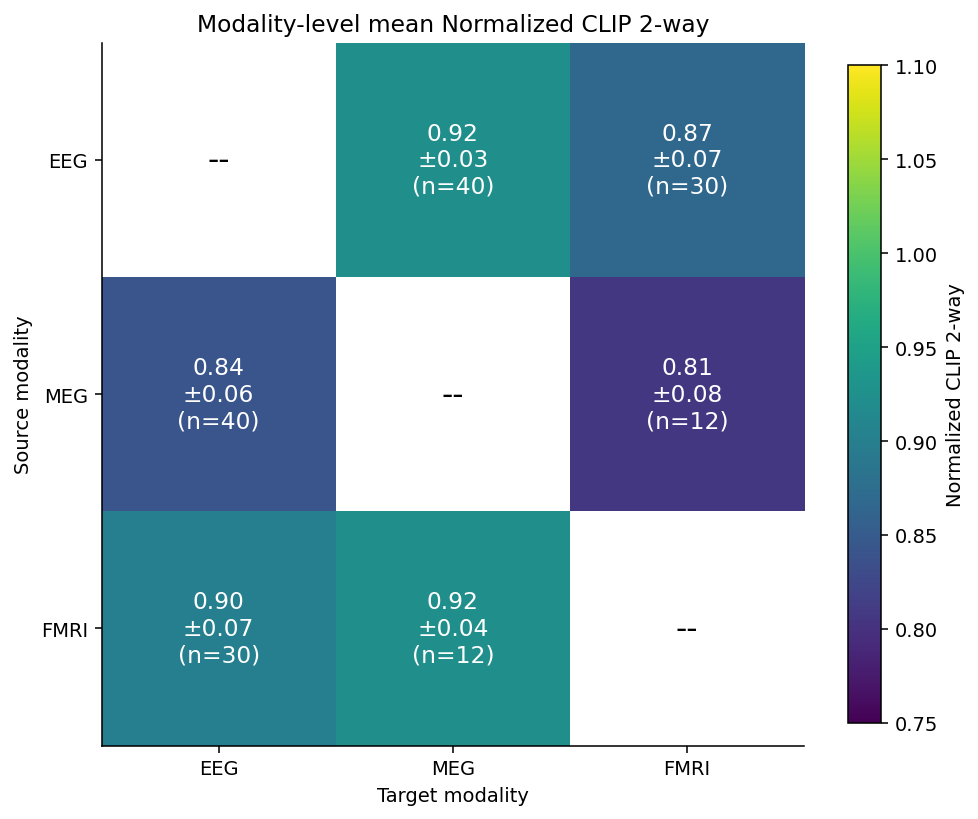

In [7]:
# Modality-level normalized CLIP 2-way heatmap
# Uses the matched-scope normalization from results/summary/conversion_summary.csv.
# Set SCOPE = "three_way" if you want the 3-way version instead.

SCOPE = "pair"  # "pair" or "three_way"

modalities = ["eeg", "meg", "fmri"]
labels = [m.upper() for m in modalities]
idx = {m: i for i, m in enumerate(modalities)}

scope_df = conversion_summary[conversion_summary["evaluation_scope"] == SCOPE].copy()

mean_mat = np.full((len(modalities), len(modalities)), np.nan, dtype=float)
std_mat = np.full((len(modalities), len(modalities)), np.nan, dtype=float)
n_mat = np.zeros((len(modalities), len(modalities)), dtype=int)

for _, row in scope_df.iterrows():
    src = row["source_modality"]
    tgt = row["target_modality"]
    i = idx[src]
    j = idx[tgt]

    mean_mat[i, j] = row["forward_normalized_two_way_mean"]
    std_mat[i, j] = row["forward_normalized_two_way_std"]
    n_mat[i, j] = int(row["count"])

    mean_mat[j, i] = row["reverse_normalized_two_way_mean"]
    std_mat[j, i] = row["reverse_normalized_two_way_std"]
    n_mat[j, i] = int(row["count"])

masked = np.ma.masked_invalid(mean_mat)
cmap = plt.cm.viridis.copy()
cmap.set_bad(color="white")

valid = mean_mat[~np.isnan(mean_mat)]
vmin = min(0.75, float(valid.min()) - 0.03)
vmax = max(1.10, float(valid.max()) + 0.03)

fig, ax = plt.subplots(figsize=(7.2, 6.0))
im = ax.imshow(masked, cmap=cmap, vmin=vmin, vmax=vmax)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xlabel("Target modality")
ax.set_ylabel("Source modality")
ax.set_title("Modality-level mean Normalized CLIP 2-way")

for i in range(len(labels)):
    for j in range(len(labels)):
        if i == j:
            ax.text(j, i, "--", ha="center", va="center", fontsize=16, color="black")
            continue

        value = mean_mat[i, j]
        if np.isnan(value):
            continue

        rgba = im.cmap(im.norm(value))
        luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        text_color = "black" if luminance > 0.6 else "white"

        ax.text(
            j,
            i,
            f"{value:.2f}\n±{std_mat[i, j]:.02f}\n(n={n_mat[i, j]})",
            ha="center",
            va="center",
            fontsize=12,
            color=text_color,
        )

cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_label("Normalized CLIP 2-way")

fig.tight_layout()
save_figure(fig, f"figA2_modality_level_normalized_two_way_{SCOPE}")
plt.show()
